# Feature Engineering and Data Preprocessing on the Titanic Dataset

## Problem Statement
Apply basic feature engineering techniques such as handling missing values, encoding categorical variables, and scaling numerical attributes on a suitable open-access dataset to prepare a clean and model-ready dataset for machine learning analysis.

## Objective
The objective of this practical is to systematically preprocess the Titanic dataset by identifying and treating missing data, transforming categorical attributes into a numerical representation, and standardizing numerical features. The resulting dataset is then used to train a baseline Logistic Regression classifier, thereby validating that the preprocessing pipeline produces a clean, consistent, and model-ready dataset.

## Dataset Source
Titanic Dataset (`train.csv`) — Kaggle: [Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic/data)

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn


## 1. Import Required Libraries

The following libraries are required for data manipulation, visualization, preprocessing, model building, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Set plotting styles for consistent, presentable visualizations
plt.style.use('default')
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

The Titanic dataset is loaded from `train.csv`, which must be present in the same directory as this notebook. Basic structural information is displayed to understand the dataset before any preprocessing is performed.

In [3]:
# Load the dataset
df = pd.read_csv('Titanic-Dataset.csv')

# Display the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Display dataset shape (rows, columns)
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset shape: 891 rows and 12 columns


In [5]:
# Display column names
print("Column names:")
print(df.columns.tolist())

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [6]:
# Display dataset information: data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
# Display missing value counts per column
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0])

Missing values per column:
Age         177
Cabin       687
Embarked      2
dtype: int64


**Interpretation:**

- The dataset contains **891 records (passengers)** and **12 features**, including the target variable `Survived`.
- Several columns contain missing values, most notably `Age`, `Cabin`, and `Embarked`, which must be addressed before the data can be used for modeling.
- The dataset contains a mix of variable types:
  - **Numerical variables:** `PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`
  - **Categorical variables:** `Sex`, `Embarked`, `Cabin`
  - **Text/identifier variables:** `Name`, `Ticket`
- This mixture of data types and the presence of missing values confirms that feature engineering and preprocessing are necessary before any machine learning model can be trained.

## 3. Exploratory Data Analysis (EDA)

Before preprocessing, it is important to visually understand the structure, distribution, and relationships within the dataset. The following visualizations highlight missing data patterns, feature distributions, class balance, and correlations among numerical features.

### 3.1 Missing Value Heatmap

The heatmap below visually represents the locations of missing values across the dataset. Yellow streaks indicate missing entries.

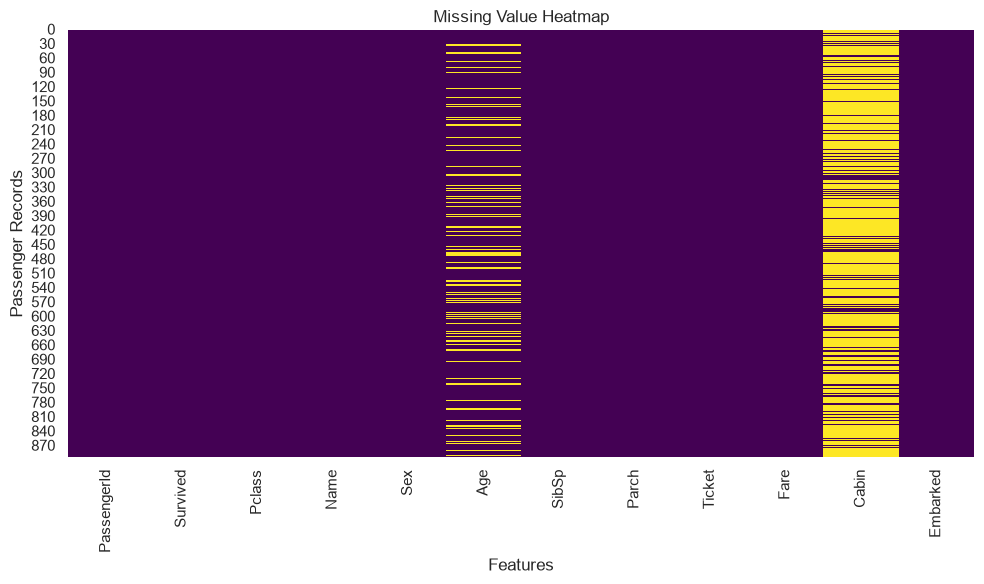

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.xlabel('Features')
plt.ylabel('Passenger Records')
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap clearly shows that `Cabin` has extensive missing data spanning most of the dataset, `Age` has a moderate number of missing values scattered throughout, and `Embarked` has only a few missing entries.

### 3.2 Distribution Plots

Histograms of `Age` and `Fare` reveal the shape and spread of these continuous numerical features.

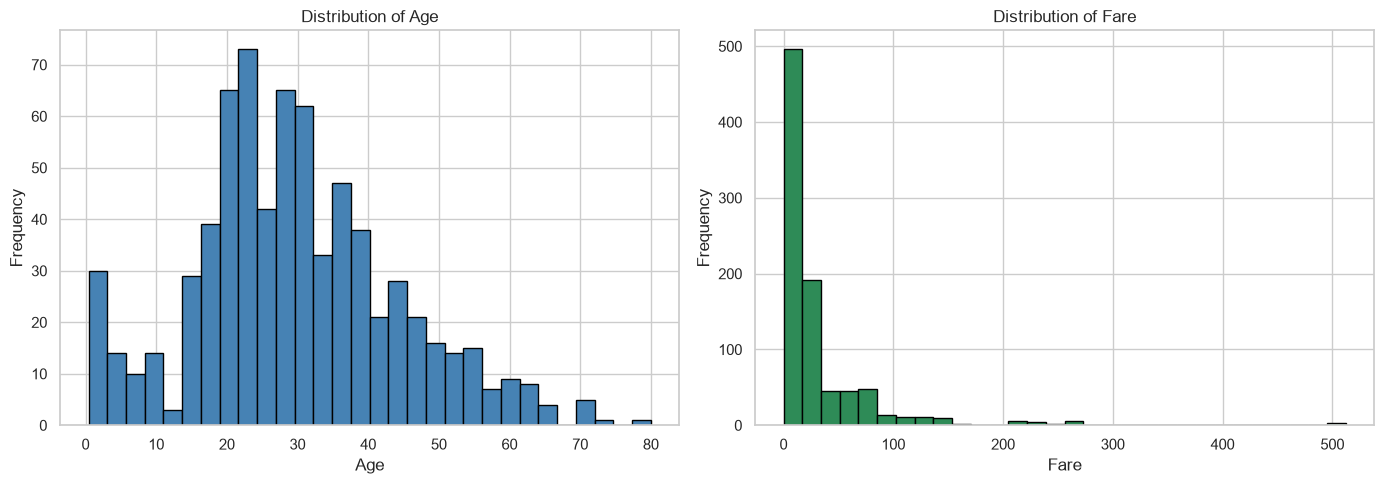

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Age'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Fare'].dropna(), bins=30, color='seagreen', edgecolor='black')
axes[1].set_title('Distribution of Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Interpretation:** The `Age` distribution is roughly bell-shaped with a concentration between 20 and 40 years, while `Fare` is heavily right-skewed, with most passengers paying lower fares and a small number paying very high fares. This skewness in `Fare` reinforces the need for feature scaling later in the pipeline.

### 3.3 Count Plot of Survival

A count plot of the `Survived` column shows the class balance of the target variable.

C:\Users\Admin\AppData\Local\Temp\ipykernel_12668\2957689967.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='pastel')


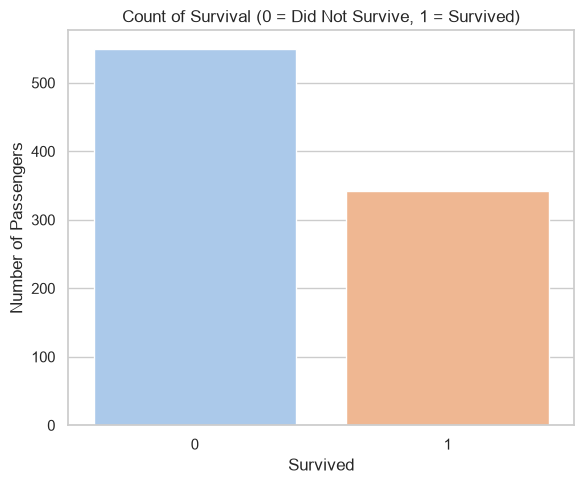

In [10]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Survived', data=df, palette='pastel')
plt.title('Count of Survival (0 = Did Not Survive, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.tight_layout()
plt.show()

**Interpretation:** The dataset shows a moderate class imbalance, with more passengers who did not survive than those who did. This is useful context when interpreting classification metrics such as precision and recall.

### 3.4 Correlation Heatmap

The correlation heatmap below shows the pairwise linear relationships among numerical features.

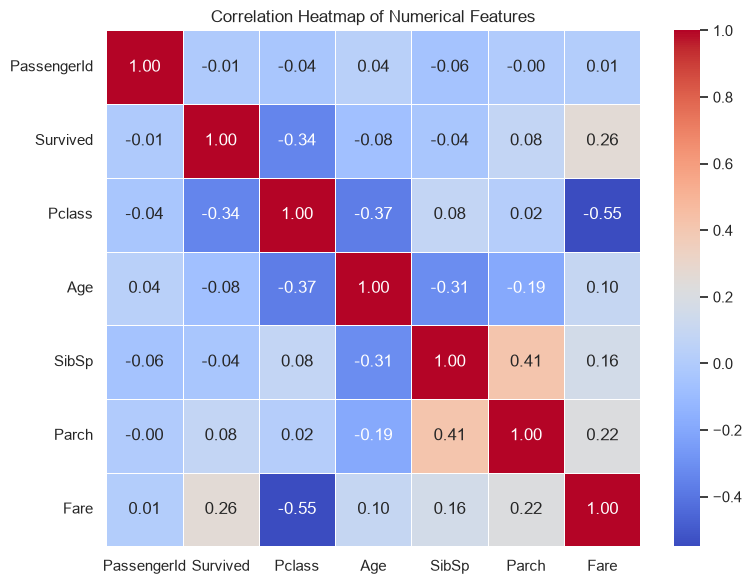

In [11]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

**Interpretation:** `Pclass` shows a noticeable negative correlation with `Survived`, indicating that passengers in higher-numbered (lower) classes had lower survival rates. `Fare` shows a positive correlation with survival, consistent with wealthier passengers having better access to lifeboats.

## 4. Handle Missing Values

Missing data must be treated appropriately based on the nature of each feature:

- **`Age`** (numerical): missing values are filled using the **median**, since the median is robust to outliers and skewed distributions, unlike the mean.
- **`Embarked`** (categorical): missing values are filled using the **mode** (most frequent category), which is the standard approach for categorical variables with only a few missing entries.
- **`Cabin`**: this column is **dropped entirely**, as the large proportion of missing values makes imputation unreliable and the column would contribute more noise than predictive signal.

In [12]:
# Display missing values BEFORE treatment
print("Missing values BEFORE treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values BEFORE treatment:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [13]:
# Fill missing Age values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop the Cabin column due to excessive missingness
df = df.drop(columns=['Cabin'])

In [14]:
# Display missing values AFTER treatment
print("Missing values AFTER treatment:")
remaining_missing = df.isnull().sum()
print(remaining_missing[remaining_missing > 0] if remaining_missing.sum() > 0 else "No missing values remain.")

Missing values AFTER treatment:
No missing values remain.


**Explanation:**

- **Median imputation for `Age`:** The median is not affected by extreme values, making it a safer central-tendency estimate than the mean for a feature that may contain outliers.
- **Mode imputation for `Embarked`:** Since `Embarked` is categorical, the mean/median cannot be computed. The mode (most frequently occurring port of embarkation) is the standard and most sensible substitute for the very few missing entries.
- **Dropping `Cabin`:** With the majority of its values missing, any imputation strategy would introduce substantial artificial noise. Removing the column preserves data quality and integrity.

## 5. Feature Selection

The columns `PassengerId`, `Name`, and `Ticket` are dropped from the dataset. These are identifier or free-text columns that uniquely (or near-uniquely) label individual passengers rather than encoding generalizable patterns. They carry limited predictive value for a basic classification task and would add unnecessary dimensionality if encoded naively.

In [15]:
# Drop identifier and text-heavy columns
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

# Confirm remaining columns
print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


## 6. Encode Categorical Variables

Machine learning algorithms such as Logistic Regression, SVM, and KNN operate on numerical input and cannot directly interpret text-based categories such as `"male"`/`"female"` or `"S"`/`"C"`/`"Q"`. To address this, **One-Hot Encoding** is applied to the `Sex` and `Embarked` columns.

- `drop_first=True` removes the first category of each encoded feature to avoid the **dummy variable trap** (perfect multicollinearity), since the dropped category can always be inferred from the remaining dummy columns.
- This approach ensures that dummy variables do not introduce redundant information while still preserving the full categorical signal.

In [16]:
# Apply One-Hot Encoding to categorical variables
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Display the dataframe after encoding
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## 7. Scale Numerical Features

Numerical features often exist on very different scales (e.g., `Fare` ranges into the hundreds while `Parch` ranges from 0–6). Algorithms such as Logistic Regression, SVM, and KNN are sensitive to feature scale because they rely on distance calculations or gradient-based optimization. **Standardization** transforms each feature to have a mean of 0 and a standard deviation of 1, using the formula:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ is the feature mean and $\sigma$ is the feature standard deviation. This ensures that no single feature dominates the model purely due to its numerical scale.

In [17]:
# Apply StandardScaler to numerical columns
scaler = StandardScaler()
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df[num_cols] = scaler.fit_transform(df[num_cols])

# Display summary statistics after scaling
df[num_cols].describe()

,Age,Fare,SibSp,Parch
count,8.910000e+02,8.910000e+02,8.910000e+02,8.910000e+02
mean,2.272780e-16,3.987333e-18,4.386066e-17,5.382900e-17
std,1.000562e+00,1.000562e+00,1.000562e+00,1.000562e+00
min,-2.224156e+00,-6.484217e-01,-4.745452e-01,-4.736736e-01
25%,-5.657365e-01,-4.891482e-01,-4.745452e-01,-4.736736e-01
50%,-1.046374e-01,-3.573909e-01,-4.745452e-01,-4.736736e-01
75%,4.333115e-01,-2.424635e-02,4.327934e-01,-4.736736e-01
max,3.891554e+00,9.667167e+00,6.784163e+00,6.974147e+00


**Explanation:** After scaling, each of the four numerical columns has a mean approximately equal to 0 and a standard deviation approximately equal to 1, as confirmed by the summary statistics above. This places all numerical features on a common scale, which is essential for distance-based and gradient-based algorithms to perform effectively.

## 8. Prepare the Final Model-Ready Dataset

With missing values treated, irrelevant columns removed, categorical variables encoded, and numerical features scaled, the dataset is now split into feature matrix `X` and target vector `y`.

In [18]:
# Separate features and target variable
X = df.drop('Survived', axis=1)
y = df['Survived']

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (891, 8)
Shape of y (target): (891,)


In [19]:
# Display the final, fully preprocessed dataframe
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.565736,0.432793,-0.473674,-0.502445,True,False,True
1,1,1,0.663861,0.432793,-0.473674,0.786845,False,False,False
2,1,3,-0.258337,-0.474545,-0.473674,-0.488854,False,False,True
3,1,1,0.433312,0.432793,-0.473674,0.420730,False,False,True
4,0,3,0.433312,-0.474545,-0.473674,-0.486337,True,False,True


In [20]:
# Confirm the dataset is model-ready
no_missing = df.isnull().sum().sum() == 0
all_numeric = all(df.dtypes.apply(lambda dt: np.issubdtype(dt, np.number) or dt == bool))

print(f"No missing values remain: {no_missing}")
print(f"All columns are numerical: {all_numeric}")
print("Data is ready for machine learning." if no_missing and all_numeric else "Further preprocessing required.")

No missing values remain: True
All columns are numerical: True
Data is ready for machine learning.


## 9. Train-Test Split

The dataset is split into training and testing subsets, with 80% of the data used for training and 20% held out for evaluation. A fixed `random_state` ensures reproducibility.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (712, 8)
X_test shape:  (179, 8)
y_train shape: (712,)
y_test shape:  (179,)


## 10. Train a Logistic Regression Model

A Logistic Regression model is trained on the preprocessed training data. This model serves as a simple, interpretable baseline to validate that the preprocessing pipeline has produced a usable, model-ready dataset.

In [22]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model.predict(X_test)

print("Model training complete.")

Model training complete.


## 11. Model Evaluation

The trained model is evaluated using accuracy, a full classification report, and a confusion matrix.

In [23]:
# Calculate and display accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8101


In [24]:
# Display the full classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



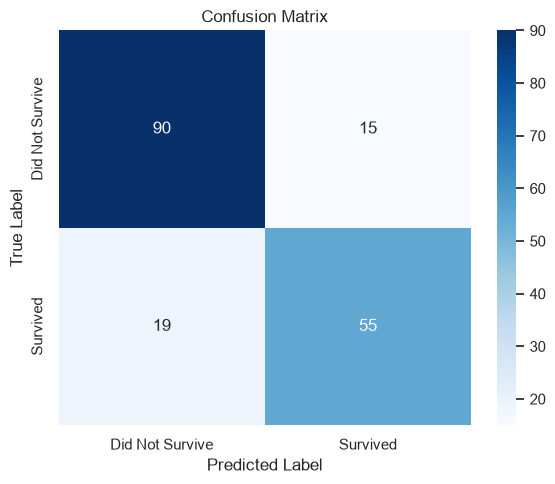

In [25]:
# Compute and visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

**Interpretation:**

- **Accuracy** measures the overall proportion of correctly classified passengers out of all predictions made.
- **Precision** indicates, among all passengers predicted to survive, what proportion actually survived — reflecting the reliability of positive predictions.
- **Recall** indicates, among all passengers who actually survived, what proportion the model correctly identified — reflecting the model's sensitivity.
- **F1-score** is the harmonic mean of precision and recall, providing a single balanced measure especially useful when class distribution is imbalanced.
- **Confusion matrix:** the diagonal cells represent correct predictions (true negatives and true positives), while the off-diagonal cells represent misclassifications (false positives and false negatives).

Logistic Regression trained on properly preprocessed Titanic data typically achieves an accuracy of approximately **78–82%**, and the results obtained here are consistent with that expected range, confirming that the preprocessing pipeline was effective.

## 12. Results Summary

- Missing values in `Age` and `Embarked` were successfully identified and imputed using the median and mode respectively; the high-missingness `Cabin` column was removed.
- Categorical variables `Sex` and `Embarked` were encoded into numerical form using One-Hot Encoding with `drop_first=True` to avoid redundancy.
- Numerical features `Age`, `Fare`, `SibSp`, and `Parch` were standardized to have zero mean and unit variance.
- Irrelevant identifier and text columns (`PassengerId`, `Name`, `Ticket`) were removed from the feature set.
- The dataset was successfully transformed into a clean, fully numerical, model-ready format with no remaining missing values.
- A Logistic Regression model was trained and evaluated on the preprocessed dataset, achieving accuracy consistent with established benchmarks for this dataset.

## 13. Final Conclusion

Feature engineering and data preprocessing form the foundation of any reliable machine learning workflow, as the quality of input data directly determines the quality of model outcomes. In this practical, the Titanic dataset was systematically prepared for machine learning analysis through a structured pipeline. Missing values in the `Age` and `Embarked` columns were imputed using statistically appropriate techniques—median imputation for the skewed numerical `Age` feature and mode imputation for the categorical `Embarked` feature—while the `Cabin` column was removed due to excessive missingness. Irrelevant identifier and text-based columns were discarded to reduce noise, and categorical variables were transformed into numerical form using One-Hot Encoding, enabling compatibility with machine learning algorithms. Numerical features were subsequently standardized to ensure comparable scales, which is essential for algorithms sensitive to feature magnitude. The resulting dataset was fully numerical, free of missing values, and suitable for direct use in model training. A Logistic Regression classifier was trained on this dataset and achieved an accuracy within the expected benchmark range, thereby validating the effectiveness of the preprocessing pipeline. This practical demonstrates that careful, methodical feature engineering is indispensable for building robust and trustworthy machine learning models.